## Assignment Data Cleansing #1 Rework

In [271]:
import pandas as pd 
import numpy as np

In [ ]:
data = pd.read_csv('../data/raw/automobileEDA_dirty_training.csv') 
data_raw = data.copy()
display(data.head())
display(data.info())

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_date   203 non-null    str    
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               203 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

None

In [273]:
inspect_data = ['symboling','normalized-losses','curb-weight','engine-size', 'city-mpg','highway-mpg','diesel','gas']
for ins in inspect_data:
    display(data[ins].value_counts())

symboling
 0    67
 1    53
 2    33
 3    27
-1    22
-2     3
Name: count, dtype: int64

normalized-losses
122    43
161    11
91      8
150     7
104     6
128     6
134     6
148     5
85      5
103     5
168     5
74      5
102     5
65      5
94      5
95      5
118     4
106     4
93      4
137     3
101     3
115     3
125     3
108     3
154     3
83      3
164     2
158     2
192     2
188     2
81      2
110     2
145     2
113     2
129     2
153     2
194     2
119     2
89      2
87      2
197     2
121     1
98      1
78      1
107     1
142     1
231     1
186     1
77      1
90      1
256     1
Name: count, dtype: int64

curb-weight
1989    4
2385    4
1918    3
2275    3
2548    2
       ..
2952    1
3049    1
3012    1
3217    1
3062    1
Name: count, Length: 169, dtype: int64

engine-size
122    16
92     15
98     14
97     14
108    13
110    12
90     11
109     8
120     7
181     7
141     7
152     6
136     6
121     6
146     6
156     5
91      5
130     4
183     4
164     3
209     3
70      3
194     3
171     3
258     2
140     2
134     2
234     2
132     2
131     1
61      1
79      1
111     1
119     1
326     1
80      1
308     1
304     1
103     1
151     1
161     1
173     1
145     1
Name: count, dtype: int64

city-mpg
19    29
31    29
24    22
27    14
17    12
23    12
26    12
21     8
30     8
25     8
28     7
37     6
16     5
38     5
22     4
18     3
20     3
15     3
29     3
36     2
14     2
47     1
49     1
13     1
45     1
32     1
35     1
34     1
33     1
Name: count, dtype: int64

highway-mpg
25    21
38    18
24    17
30    16
32    16
34    14
37    13
28    12
29    10
33     9
31     8
22     7
23     7
27     5
42     4
26     3
41     3
20     2
43     2
19     2
39     2
18     2
16     2
36     2
47     2
46     2
53     1
54     1
17     1
50     1
Name: count, dtype: int64

diesel
0    184
1     21
Name: count, dtype: int64

gas
1    184
0     21
Name: count, dtype: int64

### Memahami Dataset 

In [274]:
missing_data = data.isnull().sum()
num_duplicates = data.duplicated().sum()
n_baris, n_kolom = data.shape


print("Ukuran Awal Dataset\n")

print("------Duplicate-----\n")
print(f"Total baris yang terduplikasi : {num_duplicates}\n")
print("------Missing Data-----")
display(missing_data[missing_data>1])

print(f"Jumlah Baris :{n_baris}")
print(f"Jumlah Kolom :{n_kolom}")

Ukuran Awal Dataset

------Duplicate-----

Total baris yang terduplikasi : 4

------Missing Data-----


transaction_date    2
make                2
num-of-doors        2
stroke              4
horsepower          3
price               3
dtype: int64

Jumlah Baris :205
Jumlah Kolom :30


#### Mengkategorikan jenis kolom(numercal/categorical)

In [275]:
categorical_column = list(data_raw.select_dtypes(include="str").columns)
categorical_column += ['symboling','diesel','gas']
print("-----Categorical Column-----")
display(categorical_column)

print("-----Numerical Column-----")
numerical_column = list(data_raw.select_dtypes(include="number"))
numerical_column.remove('symboling')
numerical_column.remove('diesel')
numerical_column.remove('gas')
display(numerical_column)

-----Categorical Column-----


['transaction_date',
 'make',
 'aspiration',
 'num-of-doors',
 'body-style',
 'drive-wheels',
 'engine-location',
 'engine-type',
 'num-of-cylinders',
 'fuel-system',
 'horsepower-binned',
 'symboling',
 'diesel',
 'gas']

-----Numerical Column-----


['normalized-losses',
 'wheel-base',
 'length',
 'width',
 'height',
 'curb-weight',
 'engine-size',
 'bore',
 'stroke',
 'compression-ratio',
 'horsepower',
 'peak-rpm',
 'city-mpg',
 'highway-mpg',
 'price',
 'city-L/100km']

### Cleansing Data

In [276]:
for category in categorical_column:
    data_raw[category] = data_raw[category].fillna(data_raw[category].mode()[0])

data_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_date   205 non-null    str    
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [277]:
data_raw = data_raw.drop_duplicates()
print("Jumlah data terduplikasi :",data_raw.duplicated().sum())

Jumlah data terduplikasi : 0


In [278]:
for category in categorical_column:
    data_raw[category] = data_raw[category].astype("str").str.lower().str.strip()

data_raw.head()

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0,1
2,01-03-2025,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0,1
3,04-jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0,1


In [279]:
data_raw['transaction_date']= pd.to_datetime(data_raw['transaction_date'],dayfirst=True,format="mixed")
data_raw.head()


,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0,1
1,2025-01-02,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0,1
2,2025-03-01,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0,1
3,2025-01-04,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0,1
4,2025-05-01,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0,1


### Cleansing Numerical Data

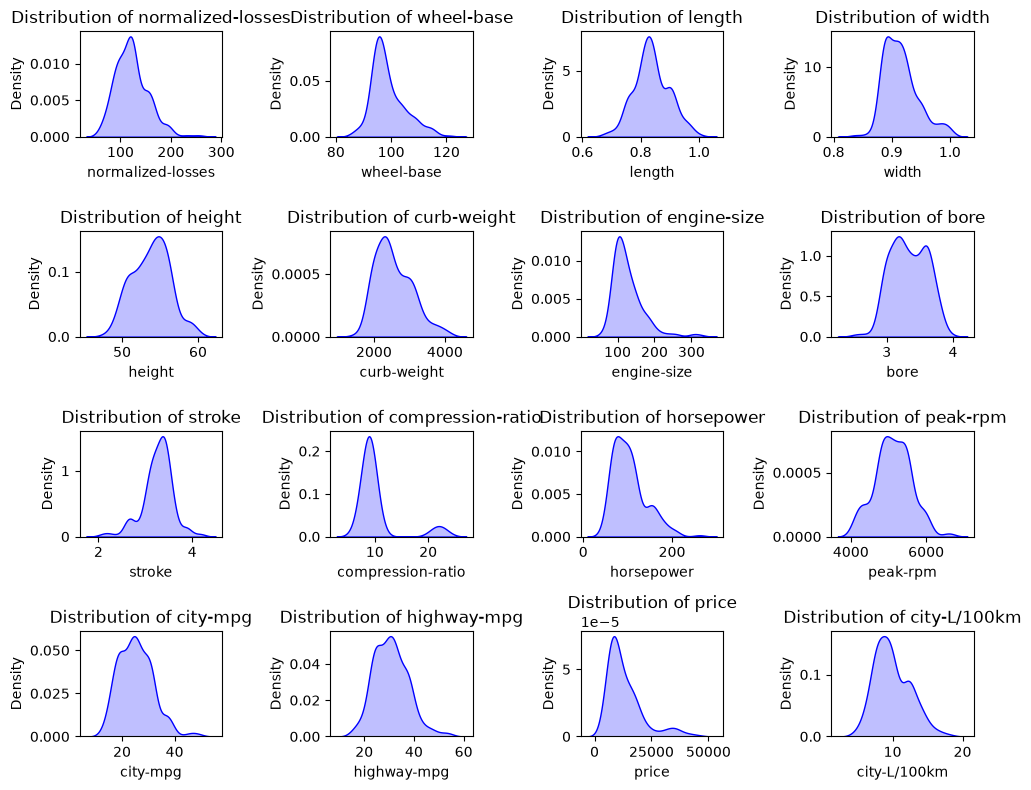

In [280]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10,8))

axes = axes.flatten()

for i, category in enumerate(numerical_column):
    sns.kdeplot(data=data_raw, x=category, fill=True, color="blue", ax= axes[i])
    axes[i].set_title(f"Distribution of {category}")

plt.tight_layout()
plt.show()

In [281]:
data_raw['stroke'] = data_raw['stroke'].fillna(data_raw['stroke'].mean())
data_raw['horsepower'] = data_raw['horsepower'].fillna(data_raw['horsepower'].median())
data_raw['price'] = data_raw['price'].fillna(data_raw['price'].median())

data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_date   201 non-null    datetime64[us]
 1   symboling          201 non-null    str           
 2   normalized-losses  201 non-null    int64         
 3   make               201 non-null    str           
 4   aspiration         201 non-null    str           
 5   num-of-doors       201 non-null    str           
 6   body-style         201 non-null    str           
 7   drive-wheels       201 non-null    str           
 8   engine-location    201 non-null    str           
 9   wheel-base         201 non-null    float64       
 10  length             201 non-null    float64       
 11  width              201 non-null    float64       
 12  height             201 non-null    float64       
 13  curb-weight        201 non-null    int64         
 14  engine-type        20

## Data Transformation

### Numarical Scalling


In [282]:
import sys
!{sys.executable} -m pip install --no-cache-dir scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [283]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_raw[numerical_column] = scaler.fit_transform(data_raw[numerical_column])

display(data_raw[numerical_column].head())

,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,0.298429,0.058309,0.413433,0.324786,0.083333,0.411171,0.260377,0.664286,0.290476,0.1250,0.294393,0.346939,0.222222,0.289474,0.207959,0.481481
1,0.298429,0.058309,0.413433,0.324786,0.083333,0.411171,0.260377,0.664286,0.290476,0.1250,0.294393,0.346939,0.222222,0.289474,0.282558,0.481481
2,0.298429,0.230321,0.449254,0.444444,0.383333,0.517843,0.343396,0.100000,0.666667,0.1250,0.495327,0.346939,0.166667,0.263158,0.282558,0.570175
3,0.518325,0.384840,0.529851,0.504274,0.541667,0.329325,0.181132,0.464286,0.633333,0.1875,0.252336,0.551020,0.305556,0.368421,0.219254,0.376157
4,0.518325,0.373178,0.529851,0.521368,0.541667,0.518231,0.283019,0.464286,0.633333,0.0625,0.313084,0.551020,0.138889,0.157895,0.306142,0.621914


In [284]:
categorical_column.remove("transaction_date")

In [285]:
for category in categorical_column:
    display(data_raw[category].value_counts())

make
toyota           34
mazda            17
nissan           17
honda            12
mitsubishi       12
subaru           12
volkswagen       12
volvo            11
peugot           10
bmw               9
dodge             9
mercedes-benz     8
audi              7
plymouth          7
saab              6
porsche           4
alfa-romero       3
chevrolet         3
jaguar            3
isuzu             2
renault           2
mercury           1
Name: count, dtype: int64

aspiration
std      165
turbo     36
Name: count, dtype: int64

num-of-doors
four    116
two      85
Name: count, dtype: int64

body-style
sedan          94
hatchback      69
wagon          24
hardtop         8
convertible     6
Name: count, dtype: int64

drive-wheels
fwd    117
rwd     75
4wd      8
awd      1
Name: count, dtype: int64

...

fuel-system
mpfi    94
2bbl    63
idi     19
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1
Name: count, dtype: int64

horsepower-binned
low       116
medium     62
high       23
Name: count, dtype: int64

symboling
0     65
1     52
2     32
3     27
-1    22
-2     3
Name: count, dtype: int64

diesel
0    181
1     20
Name: count, dtype: int64

gas
1    181
0     20
Name: count, dtype: int64

In [286]:
from sklearn.preprocessing import LabelEncoder

frequency_encoding= ["make","engine-type","fuel-system"]
one_hot = ["body-style","drive-wheels"]
label_encoding = ["aspiration","engine-location","horsepower-binned"]

#One hot 
data_raw = pd.get_dummies(data_raw, columns=one_hot)

#Fred Encoding 
for col in frequency_encoding:
    fred = data_raw[col].value_counts(normalize=True)
    data_raw[col] = data_raw[col].map(fred) 

le = LabelEncoder()

for col in label_encoding:
    data_raw[col] = le.fit_transform(data_raw[col])

data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   transaction_date        201 non-null    datetime64[us]
 1   symboling               201 non-null    str           
 2   normalized-losses       201 non-null    float64       
 3   make                    201 non-null    float64       
 4   aspiration              201 non-null    int64         
 5   num-of-doors            201 non-null    str           
 6   engine-location         201 non-null    int64         
 7   wheel-base              201 non-null    float64       
 8   length                  201 non-null    float64       
 9   width                   201 non-null    float64       
 10  height                  201 non-null    float64       
 11  curb-weight             201 non-null    float64       
 12  engine-type             201 non-null    float64       
 13  n

In [287]:
data_raw["symboling"] = data_raw["symboling"].astype("int")
data_raw["diesel"] = data_raw["diesel"].astype("int")
data_raw["gas"] = data_raw["gas"].astype("int")
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   transaction_date        201 non-null    datetime64[us]
 1   symboling               201 non-null    int64         
 2   normalized-losses       201 non-null    float64       
 3   make                    201 non-null    float64       
 4   aspiration              201 non-null    int64         
 5   num-of-doors            201 non-null    str           
 6   engine-location         201 non-null    int64         
 7   wheel-base              201 non-null    float64       
 8   length                  201 non-null    float64       
 9   width                   201 non-null    float64       
 10  height                  201 non-null    float64       
 11  curb-weight             201 non-null    float64       
 12  engine-type             201 non-null    float64       
 13  n

## Data Pipelining 

In [290]:
scaler = MinMaxScaler()
le = LabelEncoder()
frequency_encoding= ["make","engine-type","fuel-system"]
one_hot = ["body-style","drive-wheels"]
label_encoding = ["aspiration","engine-location","horsepower-binned"]

def load_data(filename):
    data = pd.read_csv("../data/raw/automobileEDA_dirty_training.csv")
    display(data.head())
    display(data.info())

    return data

def data_cleansing(data):
    data_raw = data.copy()
    for category in categorical_column:
        data_raw[category] = data_raw [category].astype("str").str.lower().str.strip()

    data_raw['transaction_date']= pd.to_datetime(data_raw['transaction_date'],dayfirst=True,format="mixed")

    for category in categorical_column:
        data_raw[category] = data_raw[category].fillna(data_raw[category].mode()[0])

    data_raw['stroke'] = data_raw['stroke'].fillna(data_raw['stroke'].mean())
    data_raw['horsepower'] = data_raw['horsepower'].fillna(data_raw['horsepower'].median())
    data_raw['price'] = data_raw['price'].fillna(data_raw['price'].median())

    return data_raw

def data_transformation(data_raw):
    data_raw[numerical_column] = scaler.fit_transform(data_raw[numerical_column])
    data_raw = pd.get_dummies(data_raw, columns=one_hot)

    #Fred Encoding 
    for col in frequency_encoding:
        fred = data_raw[col].value_counts(normalize=True)
        data_raw[col] = data_raw[col].map(fred) 
        
    le = LabelEncoder()

    for col in label_encoding:
        data_raw[col] = le.fit_transform(data_raw[col])

    return data_raw

def save_data(data_raw):
    data_raw.to_csv("../data/processed/automobile_processed.csv",index=False)

def pipelining_data(filename):
    data = load_data(filename)
    data_raw = data_cleansing(data)
    data_raw = data_transformation(data_raw)
    save_data(data_raw)

    

In [293]:
pipelining_data("automobileEDA_dirty_training.csv")

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_date   203 non-null    str    
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               203 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

None